# Short-Term Power Demand Forecasting -> Bangladesh National Grid

Name: Prem Kadam

Roll No.: 250123050

B.Tech, Mathematics and Computing, 1st Year

**Competition:** IITG.ai Predictive Paradox Recruitment Task  
**Goal:** Predict next hour's `demand_mw` using classical ML only (no LSTMs/ARIMA)  
**Metric:** MAPE  

Pipeline: data cleaning → feature engineering → LightGBM + XGBoost with Optuna hyperparameter tuning

To run the code, save all the files in MyDrive!

## 0. Setup

In [1]:
!pip install optuna lightgbm xgboost -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.6 MB/s eta 0:00:00


## 1. Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pgcb     = pd.read_excel('/content/drive/MyDrive/PGCB_date_power_demand.xlsx')
weather  = pd.read_excel('/content/drive/MyDrive/weather_data.xlsx', header=3)
economic = pd.read_csv('/content/drive/MyDrive/economic_full_1.csv')

print('PGCB shape:    ', pgcb.shape)
print('Weather shape: ', weather.shape)
print('Economic shape:', economic.shape)


Mounted at /content/drive
PGCB shape:     (92650, 15)
Weather shape:  (107304, 10)
Economic shape: (1516, 69)


## 2. Data Cleaning
The raw PGCB data mixes hourly (`:00`) and half-hourly (`:30`) readings. We combine them with a weighted average, fix outliers, and fill any missing timestamps.

In [3]:
# Separate the on-the-hour and half-hour readings
pgcb_hour = pgcb[pgcb['datetime'].dt.minute == 0].copy()
pgcb_half = pgcb[pgcb['datetime'].dt.minute == 30].copy()

# Round the :30 entries to the nearest hour so they can be merged
pgcb_half['datetime'] = pgcb_half['datetime'].dt.round('h')

# Merge and compute weighted average (on-hour counts twice)
numeric_cols = pgcb.select_dtypes(include='number').columns.tolist()
combined = pgcb_hour.merge(pgcb_half[['datetime'] + numeric_cols],
                            on='datetime', how='left', suffixes=('_h', '_30'))

for col in numeric_cols:
    h_col, m_col = col + '_h', col + '_30'
    if h_col in combined.columns and m_col in combined.columns:
        combined[col] = combined.apply(
            lambda row: (2*row[h_col] + row[m_col]) / 3
            if pd.notna(row[m_col]) else row[h_col], axis=1
        )

pgcb_clean = combined[['datetime'] + numeric_cols].copy()
print('Shape after merging half-hourly data:', pgcb_clean.shape)

# Renewables and imports are zero when not running — NaN here just means zero
for col in ['solar', 'wind', 'india_adani', 'nepal']:
    pgcb_clean[col] = pgcb_clean[col].fillna(0)

# Remove extreme outliers using 3×IQR
def fix_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
    print(f'  Outliers clipped: {((series < lower) | (series > upper)).sum()}')
    return series.clip(lower, upper)

print('Fixing demand_mw:')
pgcb_clean['demand_mw'] = fix_outliers(pgcb_clean['demand_mw'])
print('Fixing generation_mw:')
pgcb_clean['generation_mw'] = fix_outliers(pgcb_clean['generation_mw'])

# Second pass per year — catches localised logging errors the global IQR misses
# Using 0.1% threshold (not 1%) to avoid clipping real low-demand hours
pgcb_clean['demand_mw'] = pgcb_clean.groupby(
    pgcb_clean['datetime'].dt.year
)['demand_mw'].transform(lambda x: x.clip(x.quantile(0.001), x.quantile(0.999)))

# Drop duplicate timestamps and reindex to a clean hourly grid
print(f'\nDuplicates removed: {pgcb_clean.duplicated(subset="datetime").sum()}')
pgcb_clean = pgcb_clean.drop_duplicates(subset='datetime').reset_index(drop=True)

full_range = pd.date_range(start=pgcb_clean['datetime'].min(),
                           end=pgcb_clean['datetime'].max(), freq='h')
pgcb_clean = pgcb_clean.set_index('datetime').reindex(full_range).ffill().reset_index()
pgcb_clean = pgcb_clean.rename(columns={'index': 'datetime'})

print('Final shape:    ', pgcb_clean.shape)
print('Missing values:\n', pgcb_clean.isnull().sum())


Shape after merging half-hourly data: (88997, 14)
Fixing demand_mw:
  Outliers clipped: 8
Fixing generation_mw:
  Outliers clipped: 1

Duplicates removed: 951
Final shape:     (89101, 14)
Missing values:
 datetime                0
generation_mw           0
demand_mw               0
load_shedding           0
gas                     0
liquid_fuel             0
coal                    0
hydro                   0
solar                   0
wind                    0
india_bheramara_hvdc    0
india_tripura           0
india_adani             0
nepal                   0
dtype: int64


## 3. Merge Weather & Economic Data
We bring in hourly weather and annual World Bank indicators, then add calendar features.

In [4]:
weather = weather.rename(columns={'time': 'datetime'})
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather = weather.sort_values('datetime').reset_index(drop=True)

# Pick the 6 economic indicators most relevant to electricity demand
advanced_indicators = [
    'Manufacturing, value added (% of GDP)',
    'Urban population growth (annual %)',
    'Foreign direct investment, net inflows (% of GDP)',
    'Electric power transmission and distribution losses (% of output)',
    'GDP growth (annual %)',
    'Population, total'
]

eco_advanced = economic[economic['Indicator Name'].isin(advanced_indicators)]
year_cols    = [c for c in eco_advanced.columns if c.isdigit()]
eco_melted   = eco_advanced.melt(id_vars=['Indicator Name'], value_vars=year_cols,
                                  var_name='year', value_name='value')
eco_melted['year'] = eco_melted['year'].astype(int)
eco_pivoted  = eco_melted.pivot(index='year', columns='Indicator Name',
                                 values='value').reset_index()

# Calendar features — note: Friday/Saturday is the weekend in Bangladesh
pgcb_clean['year']       = pgcb_clean['datetime'].dt.year
pgcb_clean['hour']       = pgcb_clean['datetime'].dt.hour
pgcb_clean['month']      = pgcb_clean['datetime'].dt.month
pgcb_clean['dayofweek']  = pgcb_clean['datetime'].dt.dayofweek
pgcb_clean['is_weekend'] = pgcb_clean['dayofweek'].isin([4, 5]).astype(int)

# Cyclical encoding — so the model knows hour 23 and hour 0 are adjacent
pgcb_clean['hour_sin']  = np.sin(2 * np.pi * pgcb_clean['hour']  / 24)
pgcb_clean['hour_cos']  = np.cos(2 * np.pi * pgcb_clean['hour']  / 24)
pgcb_clean['month_sin'] = np.sin(2 * np.pi * pgcb_clean['month'] / 12)
pgcb_clean['month_cos'] = np.cos(2 * np.pi * pgcb_clean['month'] / 12)

final_df = pgcb_clean.merge(eco_pivoted, on='year', how='left')
final_df = final_df.merge(weather, on='datetime', how='left')

print('Final merged shape:', final_df.shape)


Final merged shape: (89101, 38)


## 4. Feature Engineering
Three groups of features:
- **Demand memory** — lags + rolling stats (what was the grid doing recently?)
- **Demand dynamics** — delta, ramp, acceleration (how fast is load changing?)
- **Thermal & calendar** — temperature lags, THI, Bangladesh seasons, peak-hour flags

In [5]:
final_df = final_df.sort_values('datetime').reset_index(drop=True)

# Demand lags — the single most important group of features
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    final_df[f'demand_lag_{lag}h'] = final_df['demand_mw'].shift(lag)

# How fast is demand changing?
final_df['demand_delta_1h'] = final_df['demand_lag_1h'] - final_df['demand_lag_2h']
final_df['demand_ramp_3h']  = (final_df['demand_lag_1h'] - final_df['demand_lag_3h']) / 3
final_df['demand_accel']    = final_df['demand_delta_1h'] - (final_df['demand_lag_2h'] - final_df['demand_lag_3h'])

# Rolling stats — shift by 1 first to avoid leaking the target into features
final_df['demand_rolling_mean_6h']  = final_df['demand_mw'].shift(1).rolling(6).mean()
final_df['demand_rolling_mean_24h'] = final_df['demand_mw'].shift(1).rolling(24).mean()
final_df['demand_rolling_std_6h']   = final_df['demand_mw'].shift(1).rolling(6).std()
final_df['demand_rolling_std_24h']  = final_df['demand_mw'].shift(1).rolling(24).std()

# Temperature lags — heat builds up gradually, AC demand follows with a delay
final_df['temp_lag_1h']          = final_df['temperature_2m (°C)'].shift(1)
final_df['temp_lag_3h']          = final_df['temperature_2m (°C)'].shift(3)
final_df['temp_rolling_mean_6h'] = final_df['temperature_2m (°C)'].shift(1).rolling(6).mean()
final_df['temp_delta_1h']        = final_df['temp_lag_1h'] - final_df['temp_lag_3h']

# Temperature-Humidity Index — captures 'feels like' heat stress on AC demand
T  = final_df['temperature_2m (°C)']
RH = final_df['relative_humidity_2m (%)']
final_df['THI'] = T - (0.55 - 0.0055 * RH) * (T - 14.5)

# Peak and ramp hour flags — from error analysis, these hours have highest prediction error
final_df['is_peak']         = final_df['hour'].between(18, 21).astype(int)
final_df['is_morning_ramp'] = final_df['hour'].between(6, 8).astype(int)
final_df['is_evening_ramp'] = final_df['hour'].between(16, 18).astype(int)

# Bangladesh-specific seasons
def get_season(month):
    if month in [12, 1, 2]:  return 0  # Winter
    elif month in [3, 4]:    return 1  # Spring
    elif month in [5, 6]:    return 2  # Pre-monsoon (hottest, most volatile)
    else:                    return 3  # Monsoon
final_df['season'] = final_df['month'].apply(get_season)

# Interaction features — same lag_1h value means different things at different hours
final_df['lag1h_x_hour_sin'] = final_df['demand_lag_1h'] * final_df['hour_sin']
final_df['lag1h_x_hour_cos'] = final_df['demand_lag_1h'] * final_df['hour_cos']
final_df['hour_x_weekend']   = final_df['hour'] * final_df['is_weekend']

# Drop the first 7 days (168h lag creates NaNs there) then fill any remaining gaps
final_df = final_df.dropna(subset=['demand_lag_168h']).reset_index(drop=True)
final_df = final_df.ffill().bfill()

print(f'Done. Final shape: {final_df.shape}')


Done. Final shape: (88933, 65)


In [6]:
import warnings
warnings.filterwarnings('ignore')

## 5. Model Training — LightGBM + XGBoost with Optuna
60 Optuna trials per model to find the best hyperparameters. Both are retrained on the full training set, and the lower MAPE wins.

In [7]:
import xgboost as xgb
import lightgbm as lgb
import optuna
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

target   = 'demand_mw'
features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'dayofweek', 'is_weekend', 'is_peak', 'is_morning_ramp', 'is_evening_ramp',
    'season', 'hour_x_weekend',
    'demand_lag_1h', 'demand_lag_2h', 'demand_lag_3h', 'demand_lag_6h',
    'demand_lag_12h', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_168h',
    'demand_delta_1h', 'demand_ramp_3h', 'demand_accel',
    'demand_rolling_mean_6h', 'demand_rolling_mean_24h',
    'demand_rolling_std_6h',  'demand_rolling_std_24h',
    'temperature_2m (°C)', 'apparent_temperature (°C)', 'relative_humidity_2m (%)',
    'temp_lag_1h', 'temp_lag_3h', 'temp_rolling_mean_6h', 'temp_delta_1h', 'THI',
    'Manufacturing, value added (% of GDP)',
    'Urban population growth (annual %)',
    'Foreign direct investment, net inflows (% of GDP)',
    'lag1h_x_hour_sin', 'lag1h_x_hour_cos',
]

# Train on everything up to end of 2023, test on 2024 onwards
train_data = final_df[final_df['year'] <= 2023]
test_data  = final_df[final_df['year'] >  2023]

X_train, y_train = train_data[features].values, train_data[target].values
X_test,  y_test  = test_data[features].values,  test_data[target].values

# Last 10% of training set used as Optuna's validation window
val_split        = int(len(X_train) * 0.90)
X_tr, y_tr       = X_train[:val_split], y_train[:val_split]
X_val, y_val     = X_train[val_split:], y_train[val_split:]

print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')

def lgb_objective(trial):
    params = {
        'objective': 'regression', 'metric': 'mape',
        'verbosity': -1, 'boosting_type': 'gbdt',
        'n_estimators':      trial.suggest_int('n_estimators', 500, 2000),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    return mean_absolute_percentage_error(y_val, model.predict(X_val)) * 100

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    return mean_absolute_percentage_error(y_val, model.predict(X_val)) * 100

print('\n🔍 LightGBM Optuna search (60 trials)...')
lgb_study = optuna.create_study(direction='minimize')
lgb_study.optimize(lgb_objective, n_trials=60, show_progress_bar=True)
print(f'  ✅ Best val MAPE: {lgb_study.best_value:.4f}%')
print(f'  Params: {lgb_study.best_params}')

print('\n🔍 XGBoost Optuna search (60 trials)...')
xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=60, show_progress_bar=True)
print(f'  ✅ Best val MAPE: {xgb_study.best_value:.4f}%')
print(f'  Params: {xgb_study.best_params}')

# Retrain both on the full training set with their best params
print('\n🏋️ Retraining on full training set...')

lgb_best  = {**lgb_study.best_params, 'objective': 'regression', 'metric': 'mape',
             'verbosity': -1, 'random_state': 42, 'n_jobs': -1}
lgb_model = lgb.LGBMRegressor(**lgb_best)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
lgb_mape  = mean_absolute_percentage_error(y_test, lgb_preds) * 100

xgb_best  = {**xgb_study.best_params, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
xgb_model = xgb.XGBRegressor(**xgb_best)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_mape  = mean_absolute_percentage_error(y_test, xgb_preds) * 100

# Pick the winner
if lgb_mape <= xgb_mape:
    best_model_name, predictions, best_model = 'LightGBM', lgb_preds, lgb_model
else:
    best_model_name, predictions, best_model = 'XGBoost', xgb_preds, xgb_model

best_mape = min(lgb_mape, xgb_mape)
mae       = mean_absolute_error(y_test, predictions)
rmse      = np.sqrt(mean_squared_error(y_test, predictions))

print('\n' + '='*50)
print(f'  LightGBM : {lgb_mape:.4f}%')
print(f'  XGBoost  : {xgb_mape:.4f}%')
print(f'  🏆 Winner : {best_model_name}')
print(f'  MAE      : {mae:.2f} MW')
print(f'  RMSE     : {rmse:.2f} MW')
print(f'  MAPE     : {best_mape:.4f}%')
print('='*50)


Train: 76,128 rows | Test: 12,805 rows

🔍 LightGBM Optuna search (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

  ✅ Best val MAPE: 3.8152%
  Params: {'n_estimators': 1869, 'max_depth': 9, 'learning_rate': 0.06398609902695557, 'num_leaves': 25, 'min_child_samples': 73, 'subsample': 0.7286395827299791, 'colsample_bytree': 0.8691635173522403, 'reg_alpha': 0.0013587902043978057, 'reg_lambda': 0.0011777790188634578}

🔍 XGBoost Optuna search (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

  ✅ Best val MAPE: 3.8479%
  Params: {'n_estimators': 1110, 'max_depth': 6, 'learning_rate': 0.023214368377435297, 'subsample': 0.8904909793064478, 'colsample_bytree': 0.9815256202838308, 'min_child_weight': 16, 'gamma': 0.995233106348258, 'reg_alpha': 0.19267670950176286, 'reg_lambda': 0.13604728820915318}

🏋️ Retraining on full training set...

  LightGBM : 2.6712%
  XGBoost  : 2.6748%
  🏆 Winner : LightGBM
  MAE      : 249.07 MW
  RMSE     : 474.85 MW
  MAPE     : 2.6712%


## 6. Evaluation & Visualizations

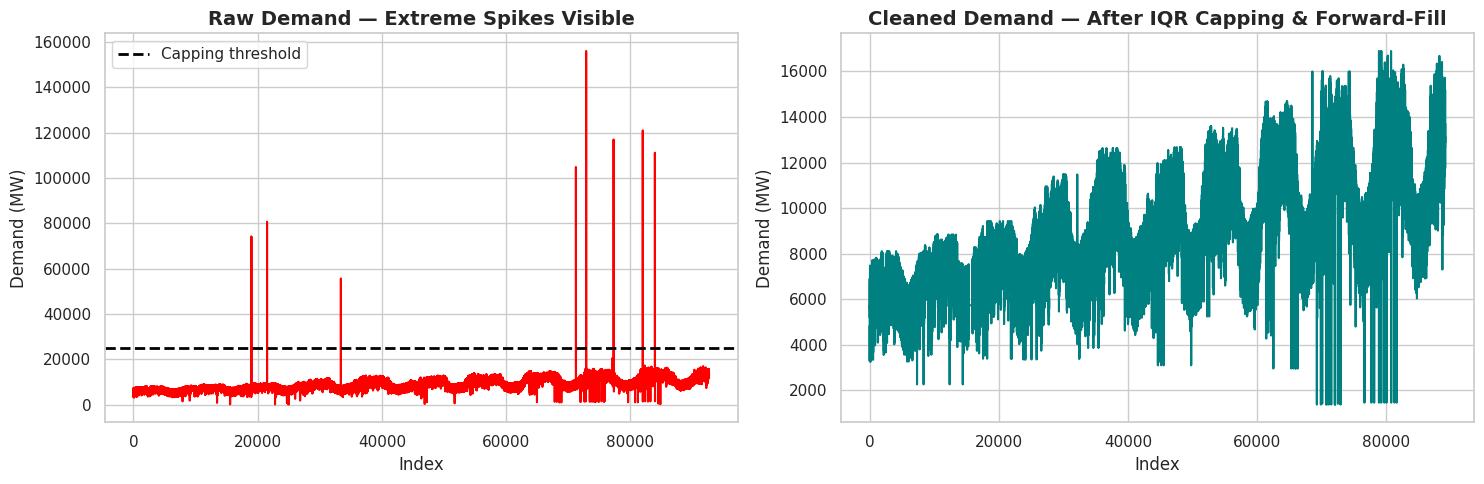

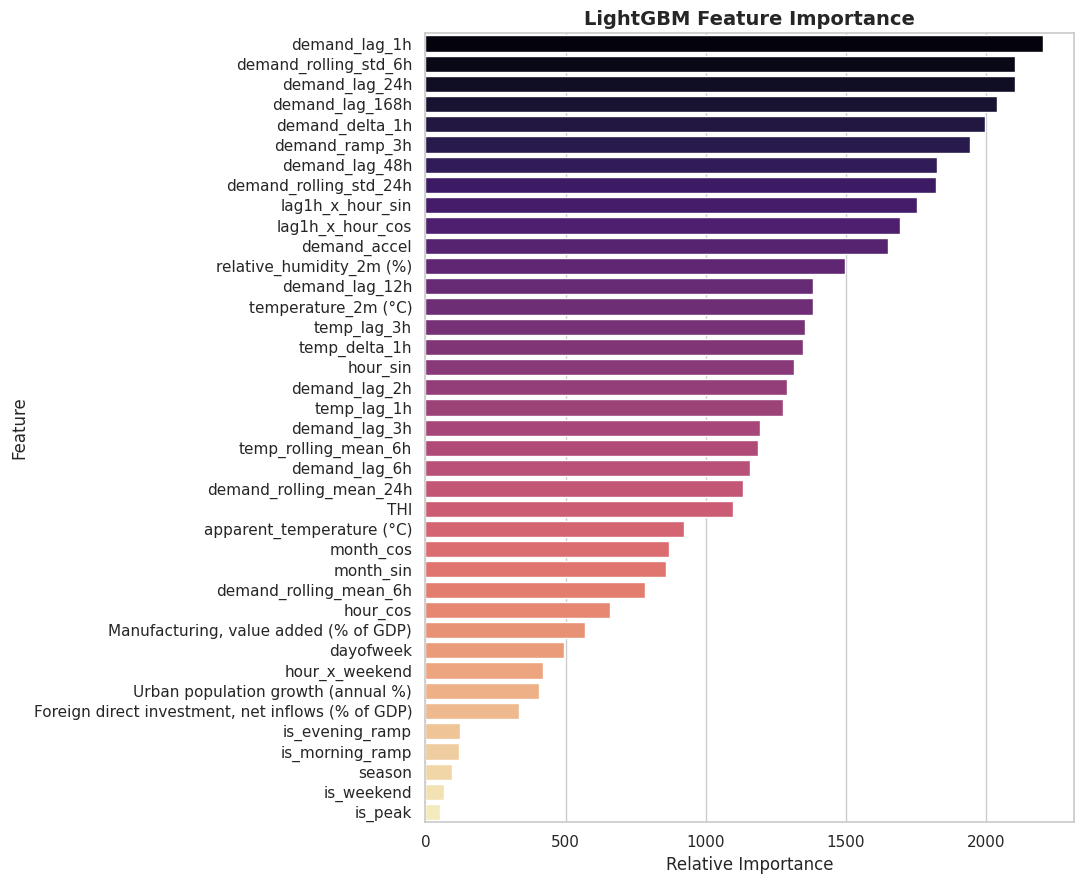

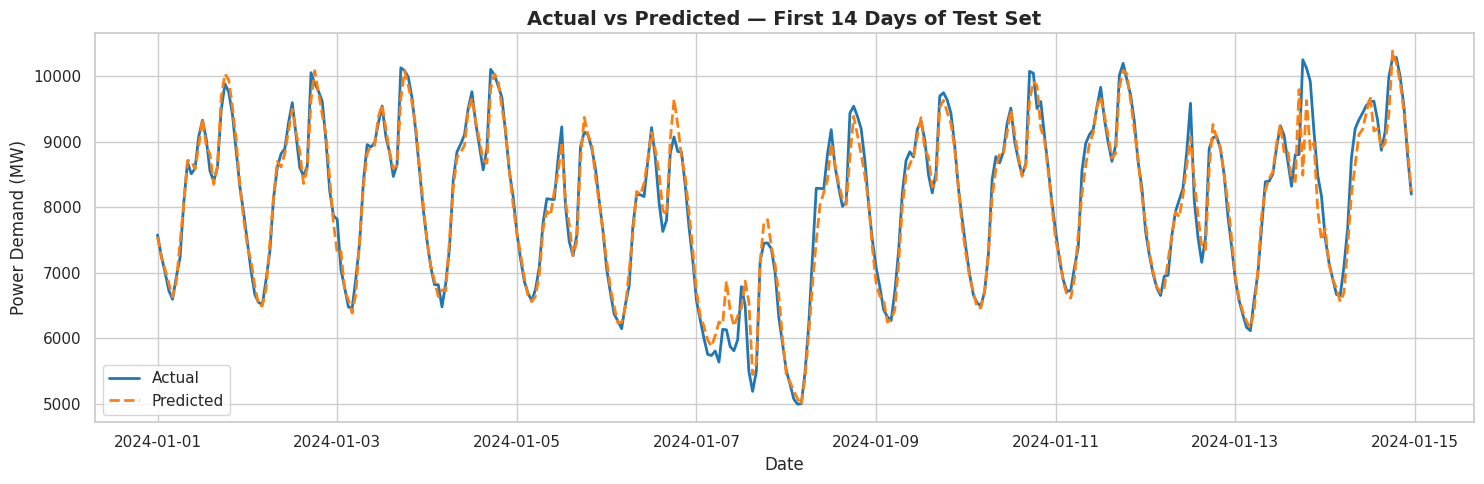

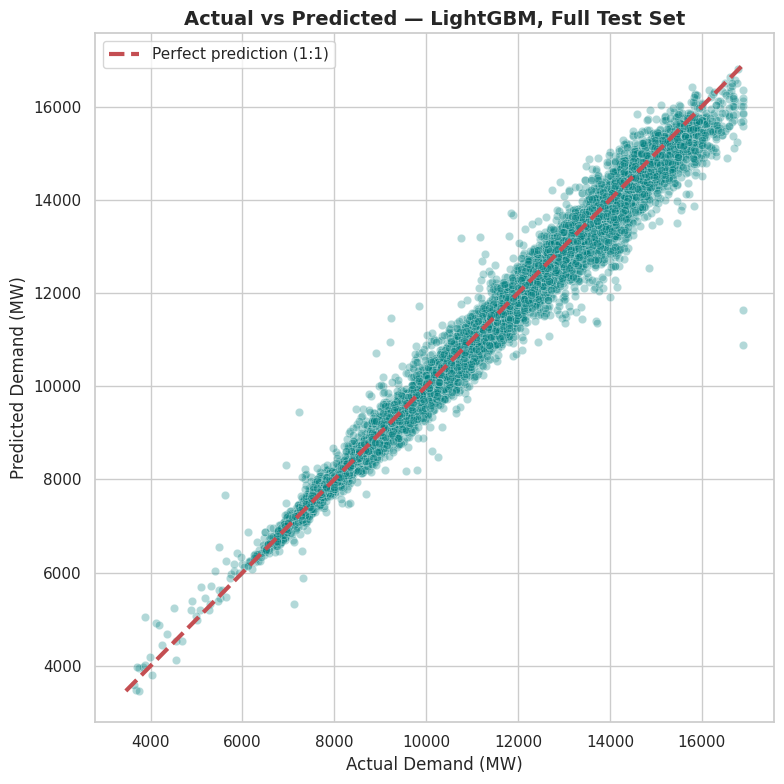

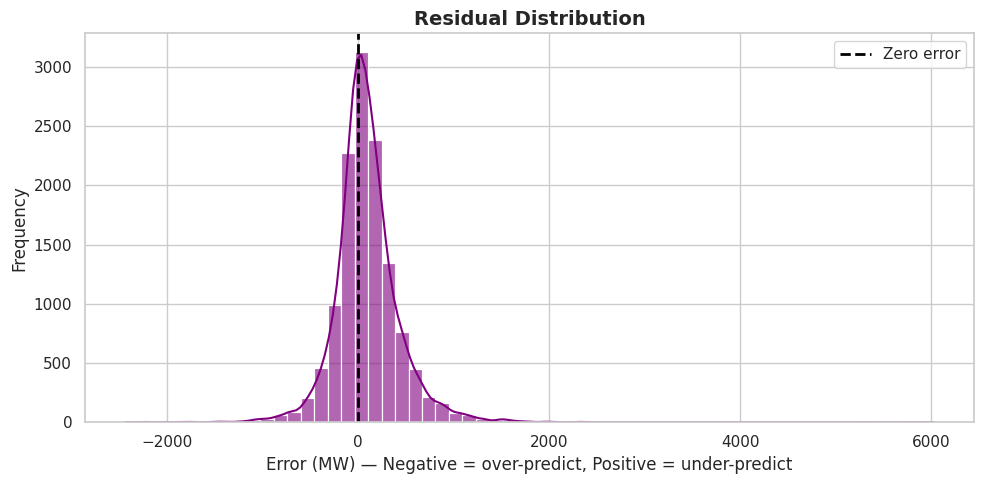

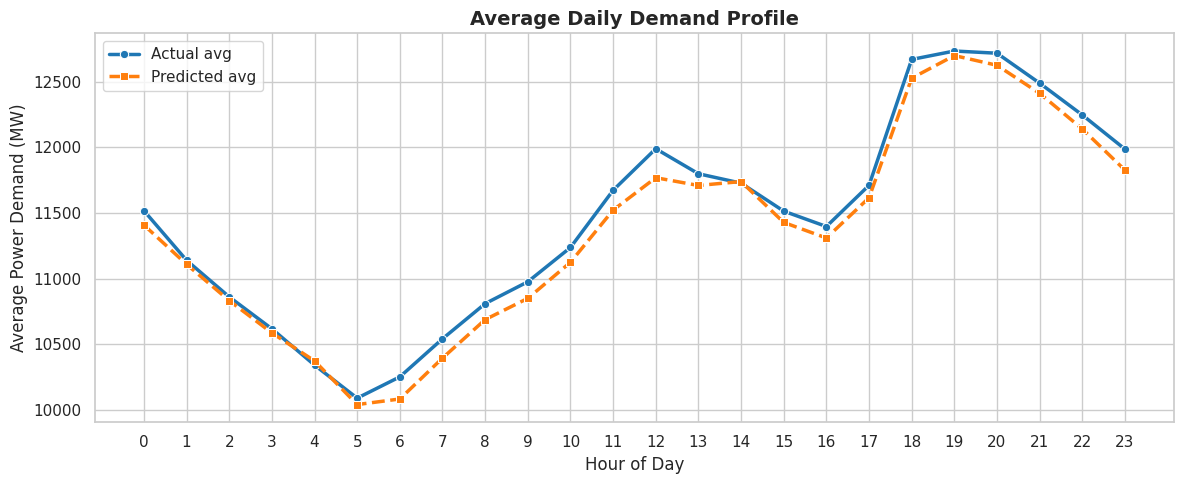


🎯 Final MAPE (LightGBM + Optuna): 2.6712%


In [8]:
import seaborn as sns
sns.set_theme(style='whitegrid')

# Plot 1: Raw vs cleaned demand
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x=pgcb.index, y=pgcb['demand_mw'], color='red')
plt.axhline(25000, color='black', linestyle='--', linewidth=2, label='Capping threshold')
plt.title('Raw Demand — Extreme Spikes Visible', fontsize=14, fontweight='bold')
plt.xlabel('Index'); plt.ylabel('Demand (MW)'); plt.legend()

plt.subplot(1, 2, 2)
sns.lineplot(data=pgcb_clean, x=pgcb_clean.reset_index().index, y='demand_mw', color='teal')
plt.title('Cleaned Demand — After IQR Capping & Forward-Fill', fontsize=14, fontweight='bold')
plt.xlabel('Index'); plt.ylabel('Demand (MW)')
plt.tight_layout(); plt.show()

# Plot 2: Feature importance
feat_df = pd.DataFrame({'Feature': features,
                        'Importance': best_model.feature_importances_}
                       ).sort_values('Importance', ascending=False)
plt.figure(figsize=(11, 9))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')
plt.title(f'{best_model_name} Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()

# Build results dataframe — fix any remaining logging errors in the 2024 test data
results_df = pd.DataFrame({
    'Datetime':         test_data['datetime'].values,
    'Actual Demand':    y_test,
    'Predicted Demand': predictions
}).sort_values('Datetime')

bad_mask = results_df['Actual Demand'] < 3000
results_df.loc[bad_mask, 'Actual Demand'] = np.nan
results_df['Actual Demand'] = results_df['Actual Demand'].ffill()
results_df['Hour']      = results_df['Datetime'].dt.hour
results_df['Residuals'] = results_df['Actual Demand'] - results_df['Predicted Demand']

# Plot 3: First 14 days of test set
plt.figure(figsize=(15, 5))
subset = results_df.head(336)
sns.lineplot(x='Datetime', y='Actual Demand',    data=subset,
             label='Actual',    color='#1f77b4', linewidth=2)
sns.lineplot(x='Datetime', y='Predicted Demand', data=subset,
             label='Predicted', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted — First 14 Days of Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Power Demand (MW)'); plt.legend()
plt.tight_layout(); plt.show()

# Plot 4: Scatter over full test set
plt.figure(figsize=(8, 8))
sns.scatterplot(x='Actual Demand', y='Predicted Demand',
                data=results_df, alpha=0.3, color='teal')
lo = results_df[['Actual Demand', 'Predicted Demand']].min().min()
hi = results_df[['Actual Demand', 'Predicted Demand']].max().max()
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=3, label='Perfect prediction (1:1)')
plt.title(f'Actual vs Predicted — {best_model_name}, Full Test Set',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Demand (MW)'); plt.ylabel('Predicted Demand (MW)'); plt.legend()
plt.tight_layout(); plt.show()

# Plot 5: Residual distribution
plt.figure(figsize=(10, 5))
sns.histplot(results_df['Residuals'], bins=60, kde=True, color='purple', alpha=0.6)
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero error')
plt.title('Residual Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Error (MW) — Negative = over-predict, Positive = under-predict')
plt.ylabel('Frequency'); plt.legend()
plt.tight_layout(); plt.show()

# Plot 6: Average hourly demand profile
plt.figure(figsize=(12, 5))
hourly_avg = results_df.groupby('Hour')[['Actual Demand', 'Predicted Demand']].mean().reset_index()
sns.lineplot(x='Hour', y='Actual Demand',    data=hourly_avg, marker='o',
             label='Actual avg',    color='#1f77b4', linewidth=2.5)
sns.lineplot(x='Hour', y='Predicted Demand', data=hourly_avg, marker='s',
             label='Predicted avg', color='#ff7f0e', linestyle='--', linewidth=2.5)
plt.title('Average Daily Demand Profile', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day'); plt.ylabel('Average Power Demand (MW)')
plt.xticks(range(0, 24)); plt.legend()
plt.tight_layout(); plt.show()

print(f'\n🎯 Final MAPE ({best_model_name} + Optuna): {best_mape:.4f}%')
